In [1]:
import requests
import pandas as pd

url = "https://api.unhcr.org/population/v1/population/"


In [2]:
all_items = []
for page in range(1, 8):
    params = {
        'limit': 1000,
        'year': 2023,
        'coo_all': 'true',
        'coa_all': 'true',
        'page': page
    }
    response = requests.get(url, params=params)
    items = response.json()['items']
    all_items.extend(items)
    print(f"Page {page}: got {len(items)} records")

print(f"\nTotal: {len(all_items)} records")

Page 1: got 1000 records
Page 2: got 1000 records
Page 3: got 1000 records
Page 4: got 1000 records
Page 5: got 1000 records
Page 6: got 1000 records
Page 7: got 49 records

Total: 6049 records


In [3]:
df = pd.DataFrame(all_items)

In [4]:
df.head()

,year,coo_id,coo_name,coo,coo_iso,coa_id,coa_name,coa,coa_iso,refugees,asylum_seekers,returned_refugees,idps,returned_idps,stateless,ooc,oip,hst
0,2023,2,Afghanistan,AFG,AFG,2,Afghanistan,AFG,AFG,0,0,0,3222397,31605,0,33712,-,1584157
1,2023,2,Afghanistan,AFG,AFG,3,Albania,ALB,ALB,5,0,0,0,0,0,0,-,0
2,2023,2,Afghanistan,AFG,AFG,8,Egypt,ARE,EGY,34,438,0,0,0,0,0,-,0
3,2023,2,Afghanistan,AFG,AFG,9,Argentina,ARG,ARG,19,10,0,0,0,0,0,-,0
4,2023,2,Afghanistan,AFG,AFG,10,Armenia,ARM,ARM,9,0,0,0,0,0,0,-,0


In [5]:
print(df.shape)
df.dtypes

(6049, 18)


year                  int64
coo_id                int64
coo_name             object
coo                  object
coo_iso              object
coa_id                int64
coa_name             object
coa                  object
coa_iso              object
refugees             object
asylum_seekers       object
returned_refugees    object
idps                 object
returned_idps        object
stateless            object
ooc                  object
oip                  object
hst                  object
dtype: object

In [6]:
num_cols = ['refugees', 'asylum_seekers', 'returned_refugees', 'idps', 
            'returned_idps', 'stateless', 'ooc', 'oip', 'hst']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df.dtypes

year                   int64
coo_id                 int64
coo_name              object
coo                   object
coo_iso               object
coa_id                 int64
coa_name              object
coa                   object
coa_iso               object
refugees               int64
asylum_seekers         int64
returned_refugees      int64
idps                   int64
returned_idps          int64
stateless              int64
ooc                    int64
oip                  float64
hst                    int64
dtype: object

In [8]:
df.nlargest(10, 'refugees')[['coo_name', 'coa_name', 'refugees']]

,coo_name,coa_name,refugees
43,Afghanistan,Iran (Islamic Rep. of),3752317
5143,Syrian Arab Rep.,Türkiye,3214780
73,Afghanistan,Pakistan,1987717
5701,Ukraine,Russian Federation,1227554
5661,Ukraine,Germany,1097503
3636,Myanmar,Bangladesh,971964
5698,Ukraine,Poland,955891
4771,South Sudan,Uganda,923607
4890,Sudan,Chad,923323
5093,Syrian Arab Rep.,Lebanon,784884


In [9]:
print('Total rows:', len(df))
print('Rows with refugees > 0:', (df['refugees'] > 0).sum())
print('Rows with refugees == 0:', (df['refugees'] == 0).sum())

Total rows: 6049
Rows with refugees > 0: 4641
Rows with refugees == 0: 1408


In [10]:
refugees_only = df[df['refugees'] > 0]['refugees']
print(refugees_only.describe())

count    4.641000e+03
mean     6.816938e+03
std      9.098545e+04
min      5.000000e+00
25%      8.000000e+00
50%      2.600000e+01
75%      1.760000e+02
max      3.752317e+06
Name: refugees, dtype: float64


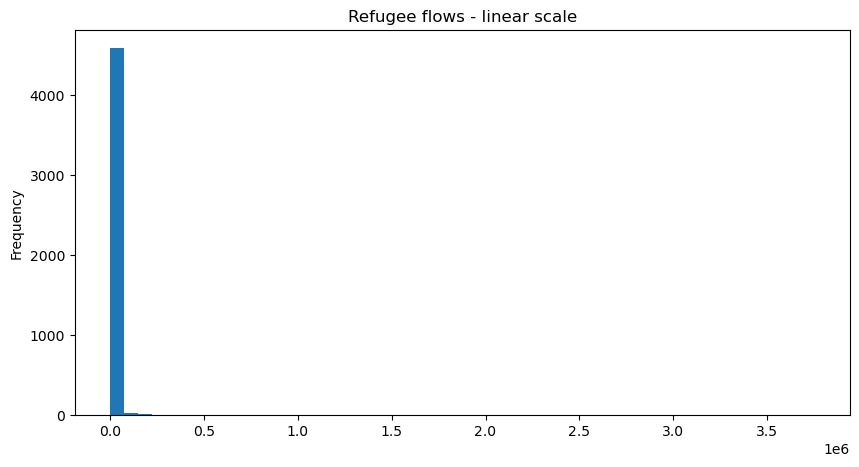

In [11]:
import matplotlib.pyplot as plt

refugees_only.plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Refugee flows - linear scale')
plt.show()

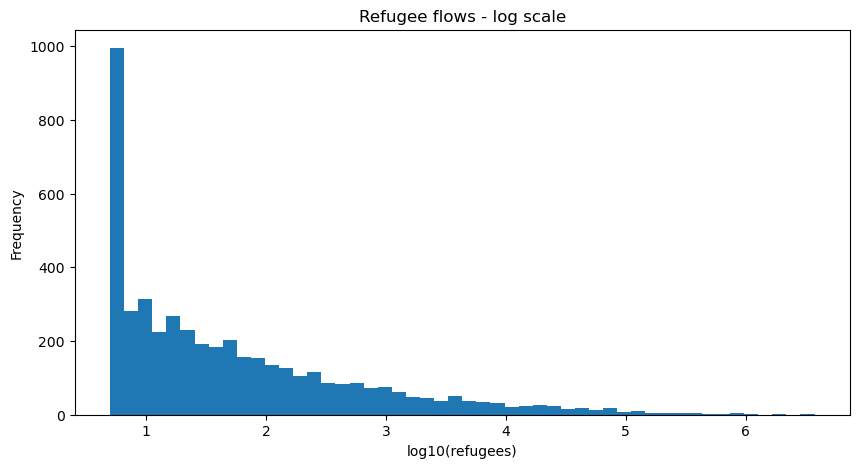

In [12]:
import numpy as np

np.log10(refugees_only).plot(kind='hist', bins=50, figsize=(10,5))
plt.xlabel('log10(refugees)')
plt.title('Refugee flows - log scale')
plt.show()

In [13]:
for threshold in [5, 50, 100, 500, 1000, 10000]:
    count = (refugees_only >= threshold).sum()
    print(f"Flows >= {threshold:>6,}: {count:>4} edges")

Flows >=      5: 4641 edges
Flows >=     50: 1865 edges
Flows >=    100: 1429 edges
Flows >=    500:  789 edges
Flows >=  1,000:  580 edges
Flows >= 10,000:  205 edges


In [14]:
import networkx as nx

threshold = 1000
flows = df[df['refugees'] >= threshold].copy()

G = nx.DiGraph()
for _, row in flows.iterrows():
    G.add_edge(row['coo_name'], row['coa_name'], weight=row['refugees'])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 143
Edges: 580


In [15]:
# Top origins (most outgoing edges)
out_deg = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print("Top origins (flee TO most countries):")
for country, degree in out_deg:
    print(f"  {country}: → {degree} countries")

print()

# Top destinations (most incoming edges)
in_deg = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
print("Top destinations (receive FROM most countries):")
for country, degree in in_deg:
    print(f"  {country}: ← {degree} countries")

Top origins (flee TO most countries):
  Ukraine: → 46 countries
  Syrian Arab Rep.: → 35 countries
  Afghanistan: → 34 countries
  Somalia: → 24 countries
  Dem. Rep. of the Congo: → 23 countries
  Eritrea: → 21 countries
  Iraq: → 21 countries
  Iran (Islamic Rep. of): → 17 countries
  Sudan: → 17 countries
  Ethiopia: → 17 countries

Top destinations (receive FROM most countries):
  France: ← 55 countries
  United States of America: ← 47 countries
  Germany: ← 41 countries
  United Kingdom of Great Britain and Northern Ireland: ← 27 countries
  Italy: ← 26 countries
  Canada: ← 18 countries
  Switzerland: ← 16 countries
  Belgium: ← 15 countries
  Greece: ← 15 countries
  Spain: ← 15 countries


In [16]:
# Top destinations by total volume
for node in G.nodes():
    total = sum(d['weight'] for _, _, d in G.in_edges(node, data=True))
    G.nodes[node]['total_received'] = total

top_volume = sorted(G.nodes(data=True), key=lambda x: x[1].get('total_received', 0), reverse=True)[:10]
print("Top destinations by VOLUME:")
for country, data in top_volume:
    deg = G.in_degree(country)
    print(f"  {country}: {data['total_received']:>10,} refugees from {deg} countries")

Top destinations by VOLUME:
  Iran (Islamic Rep. of):  3,764,492 refugees from 2 countries
  Türkiye:  3,251,127 refugees from 6 countries
  Germany:  2,573,732 refugees from 41 countries
  Pakistan:  1,987,717 refugees from 1 countries
  Uganda:  1,576,406 refugees from 8 countries
  Russian Federation:  1,228,787 refugees from 2 countries
  Chad:  1,099,496 refugees from 4 countries
  Ethiopia:    978,687 refugees from 6 countries
  Bangladesh:    971,964 refugees from 1 countries
  Poland:    967,678 refugees from 4 countries


In [17]:
import matplotlib.pyplot as plt

# Start with just the biggest flows to keep it readable
big_flows = df[df['refugees'] >= 10000].copy()
G_vis = nx.DiGraph()
for _, row in big_flows.iterrows():
    G_vis.add_edge(row['coo_name'], row['coa_name'], weight=row['refugees'])

print(f"Nodes: {G_vis.number_of_nodes()}, Edges: {G_vis.number_of_edges()}")

Nodes: 110, Edges: 205


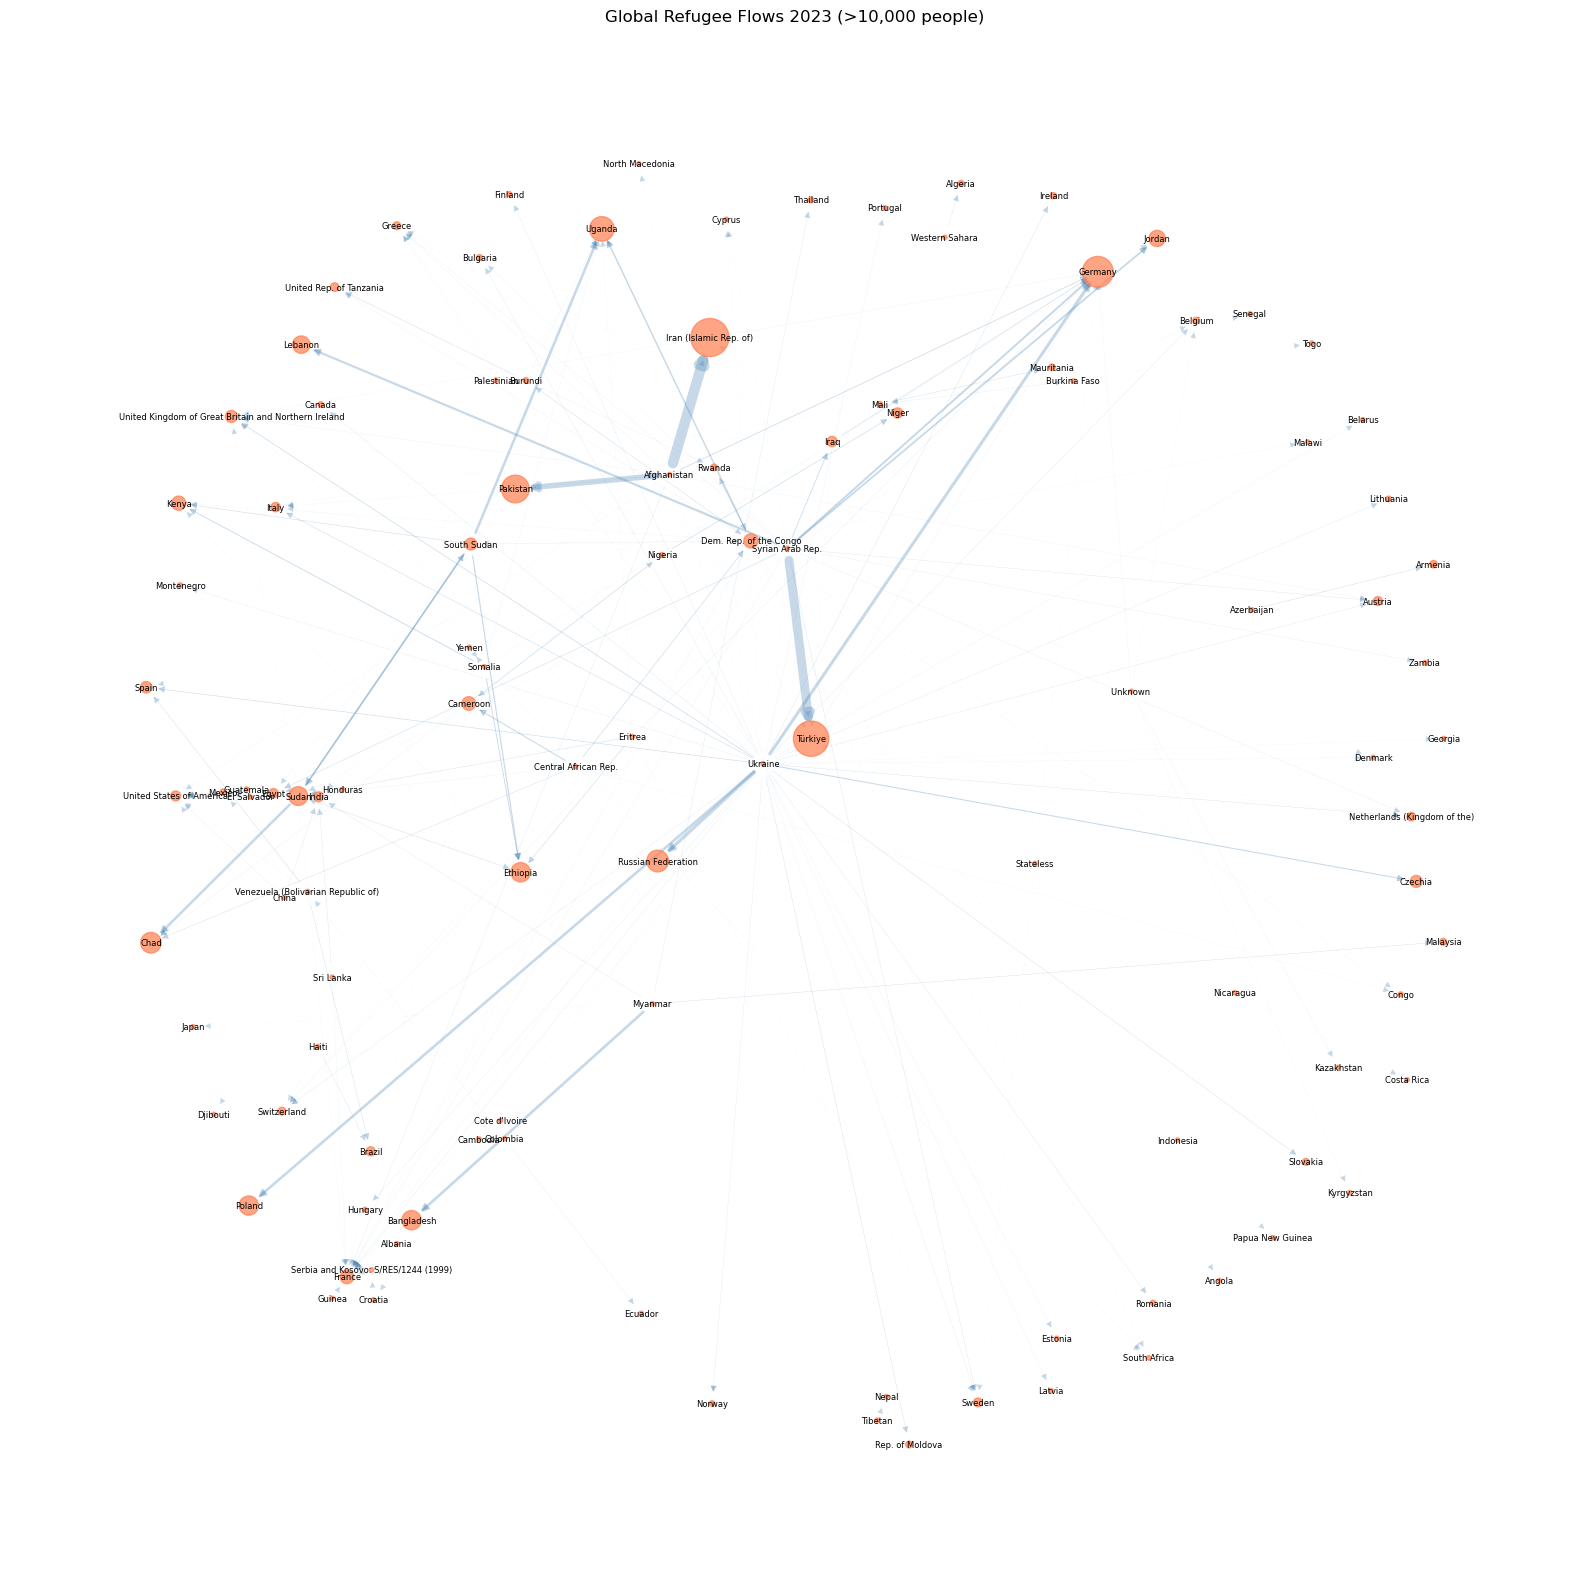

In [18]:
plt.figure(figsize=(16, 16))

pos = nx.spring_layout(G_vis, k=2, seed=42, iterations=50)

# Scale node size by total incoming refugees
node_sizes = []
for node in G_vis.nodes():
    incoming = sum(d['weight'] for _, _, d in G_vis.in_edges(node, data=True))
    node_sizes.append(max(incoming / 5000, 10))

# Scale edge width by flow size
edge_weights = [G_vis[u][v]['weight'] / 500000 for u, v in G_vis.edges()]

nx.draw_networkx_edges(G_vis, pos, alpha=0.3, width=edge_weights, 
                        edge_color='steelblue', arrows=True, arrowsize=10)
nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, 
                        node_color='coral', alpha=0.7)
nx.draw_networkx_labels(G_vis, pos, font_size=6)

plt.title("Global Refugee Flows 2023 (>10,000 people)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
from pyvis.network import Network

net = Network(height='800px', width='100%', directed=True, notebook=True, cdn_resources='in_line', bgcolor='#ffffff')
net.from_nx(G_vis)

# Color the edges
for edge in net.edges:
    edge['color'] = 'steelblue'

net.show('refugees.html')

refugees.html


In [21]:
matrix = df[df['refugees'] >= 1000].pivot_table(
    index='coo_name', 
    columns='coa_name', 
    values='refugees', 
    fill_value=0
)
print(matrix.shape)

(88, 117)


In [22]:
only_origin = set(matrix.index) - set(matrix.columns)
only_destination = set(matrix.columns) - set(matrix.index)
print(f"Only origins: {len(only_origin)}")
print(f"Only destinations: {len(only_destination)}")

Only origins: 26
Only destinations: 55


In [23]:
print("Only origins (send but don't receive 1000+):")
print(sorted(only_origin))
print()
print("Only destinations (receive but don't send 1000+):")
print(sorted(only_destination))

Only origins (send but don't receive 1000+):
['Bhutan', 'Bosnia and Herzegovina', 'Cambodia', 'China', 'Comoros', 'Cuba', 'El Salvador', 'Eritrea', 'Guatemala', 'Guinea-Bissau', 'Haiti', 'Honduras', 'Kuwait', "Lao People's Dem. Rep.", 'Liberia', 'Libya', 'Myanmar', 'Nicaragua', 'Palestinian', 'Sierra Leone', 'Sri Lanka', 'Stateless', 'Tibetan', 'Unknown ', 'Viet Nam', 'Western Sahara']

Only destinations (receive but don't send 1000+):
['Australia', 'Austria', 'Belgium', 'Benin', 'Bulgaria', 'Canada', 'Chile', 'Costa Rica', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Jordan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malawi', 'Malaysia', 'Malta', 'Montenegro', 'Mozambique', 'Namibia', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Rep. of Korea', 'Romania', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Swede